# a better version of feedback simulator

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
tc_dir = os.path.join(data_dir,'derivatives','timecourses')
output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['AA','UA']
hrf_delay = 3 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [3]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

df = pd.DataFrame(columns=['subject','tr','run','left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1'])

for ss,subject in enumerate(subject_list):
    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-zscoresample_ss.npy")
            tc = np.load(tc_file)

            # estimate percent signal change for each roi (mean = 100, variation relative to mean, as in TBV)
            # tc_0 = tc[:,0] / abs(np.mean(tc[:,0])) * 100
            # tc_1 = tc[:,1] / abs(np.mean(tc[:,1])) * 100
            # tc_2 = tc[:,2] / abs(np.mean(tc[:,2])) * 100
            # tc_3 = tc[:,3] / abs(np.mean(tc[:,3])) * 100

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, tc[:,0], tc[:,1], tc[:,2], tc[:,3], tc_mean1, tc_mean2]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

In [4]:
# tests
tc_file = os.path.join(tc_dir,'sub-01_0.5_AA_hp_ss.npy')
tc = np.load(tc_file)

# estimate percent signal change for each roi (mean = 100, variation relative to mean, as in TBV)
tc_0 = tc[:,0] / np.mean(tc[:,0]) * 100
tc_1 = tc[:,1] / np.mean(tc[:,1]) * 100

# mean of tc_0 and tc_1
tc_mean = np.mean([tc_0,tc_1],axis=0)

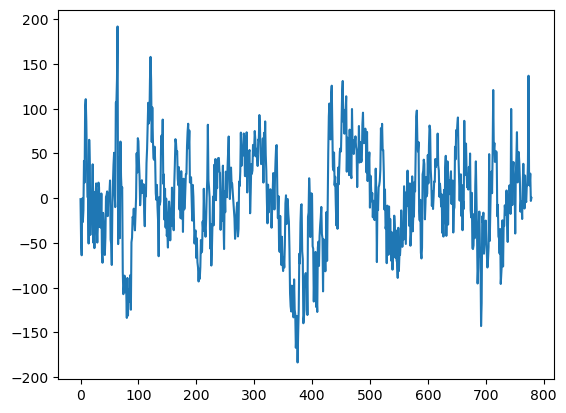

In [5]:
plt.plot(tc[:,0])

In [6]:
df

,subject,tr,run,left_mt,right_mt,left_v1,right_v1,bilateral_mt,bilateral_v1
0,sub-01,0.50,AA,"[-0.02192659, -0.9028005, -1.1735966, -0.00696...","[-0.21389443, -0.56126136, -1.0073587, 0.76775...","[0.14670314, -0.079061784, -0.8500375, -1.1255...","[0.16285735, 0.42411727, -1.2756435, -0.88972,...","[-0.117910504, -0.7320309, -1.0904777, 0.38039...","[0.15478024, 0.17252775, -1.0628405, -1.007641..."
1,sub-01,0.50,UA,"[-0.33926728, -1.1907738, -0.7945119, 1.091168...","[-0.43873116, -1.0981828, -1.5963974, 0.187625...","[0.10486642, 0.23840159, -0.21122286, -1.15020...","[-0.023075555, 0.06286354, -0.2364837, -0.6602...","[-0.38899922, -1.1444783, -1.1954546, 0.639397...","[0.040895432, 0.15063256, -0.22385328, -0.9052..."
2,sub-01,0.75,AA,"[0.47494593, 0.36776116, -1.0770807, -0.958189...","[0.36362547, 1.5238305, 0.5894786, -1.0170022,...","[0.3808922, -0.5789473, -1.7880038, -2.1613722...","[0.16938302, -0.8286955, -2.7909071, -1.564552...","[0.4192857, 0.94579583, -0.24380106, -0.987595...","[0.2751376, -0.7038214, -2.2894554, -1.8629625..."
3,sub-01,0.75,UA,"[-0.4330306, -0.4626376, 0.15811814, -0.247110...","[-0.47105327, -0.4001197, 0.8808069, 0.0386810...","[0.115366526, 0.63999164, -2.8293428, -2.01455...","[-0.13341802, 0.54886806, -2.4319155, -1.69323...","[-0.45204192, -0.43137866, 0.5194625, -0.10421...","[-0.009025749, 0.59442985, -2.630629, -1.85389..."
4,sub-01,1.00,AA,"[0.37077552, -1.6605964, -1.2044413, -1.315620...","[0.22472583, -1.2906649, -1.0526568, -1.397171...","[0.33921772, -2.9110289, -2.449073, -1.1473069...","[0.28145066, -2.3736267, -2.1976523, -0.936507...","[0.29775068, -1.4756306, -1.1285491, -1.356396...","[0.3103342, -2.6423278, -2.3233628, -1.0419072..."
...,...,...,...,...,...,...,...,...,...
115,sub-23,0.75,UA,"[-0.30126986, -0.6596954, -0.6489556, -0.93533...","[-0.6394379, -0.997845, -1.6691016, -0.4489013...","[-0.06757785, -0.91091675, -2.0063374, -2.4229...","[-0.03645008, -0.84763503, -1.3820305, -1.8278...","[-0.4703539, -0.82877016, -1.1590285, -0.69211...","[-0.052013963, -0.8792759, -1.694184, -2.12542..."
116,sub-23,1.00,AA,"[-0.36860573, 0.022752076, -0.24617143, -0.449...","[-0.35735106, 0.42639259, -0.6997644, -1.05212...","[-0.35257524, -1.4432186, -2.7755268, -0.88712...","[0.08697813, -1.5524724, -2.3183205, -1.090827...","[-0.3629784, 0.22457233, -0.4729679, -0.750848...","[-0.13279855, -1.4978454, -2.5469236, -0.98897..."
117,sub-23,1.00,UA,"[-0.5689774, -0.46227255, -0.929659, -1.893497...","[-0.6027257, -1.0748881, -0.883599, -0.6803351...","[-0.8896034, -2.2192433, -0.13164902, -0.03108...","[-0.5177687, -1.0950671, -0.9772479, 0.0971998...","[-0.58585155, -0.7685803, -0.90662897, -1.2869...","[-0.703686, -1.6571553, -0.5544485, 0.03305988..."
118,sub-23,2.50,AA,"[0.01979951, -1.4100829, -0.3974143, -1.025572...","[0.11861604, -1.6939403, -1.3606256, -0.697593...","[0.14504309, -1.6257058, 0.6350674, 1.2282228,...","[0.32378325, -1.778711, -0.18620698, 0.6430063...","[0.06920777, -1.5520116, -0.87902, -0.8615829,...","[0.23441318, -1.7022084, 0.2244302, 0.9356146,..."


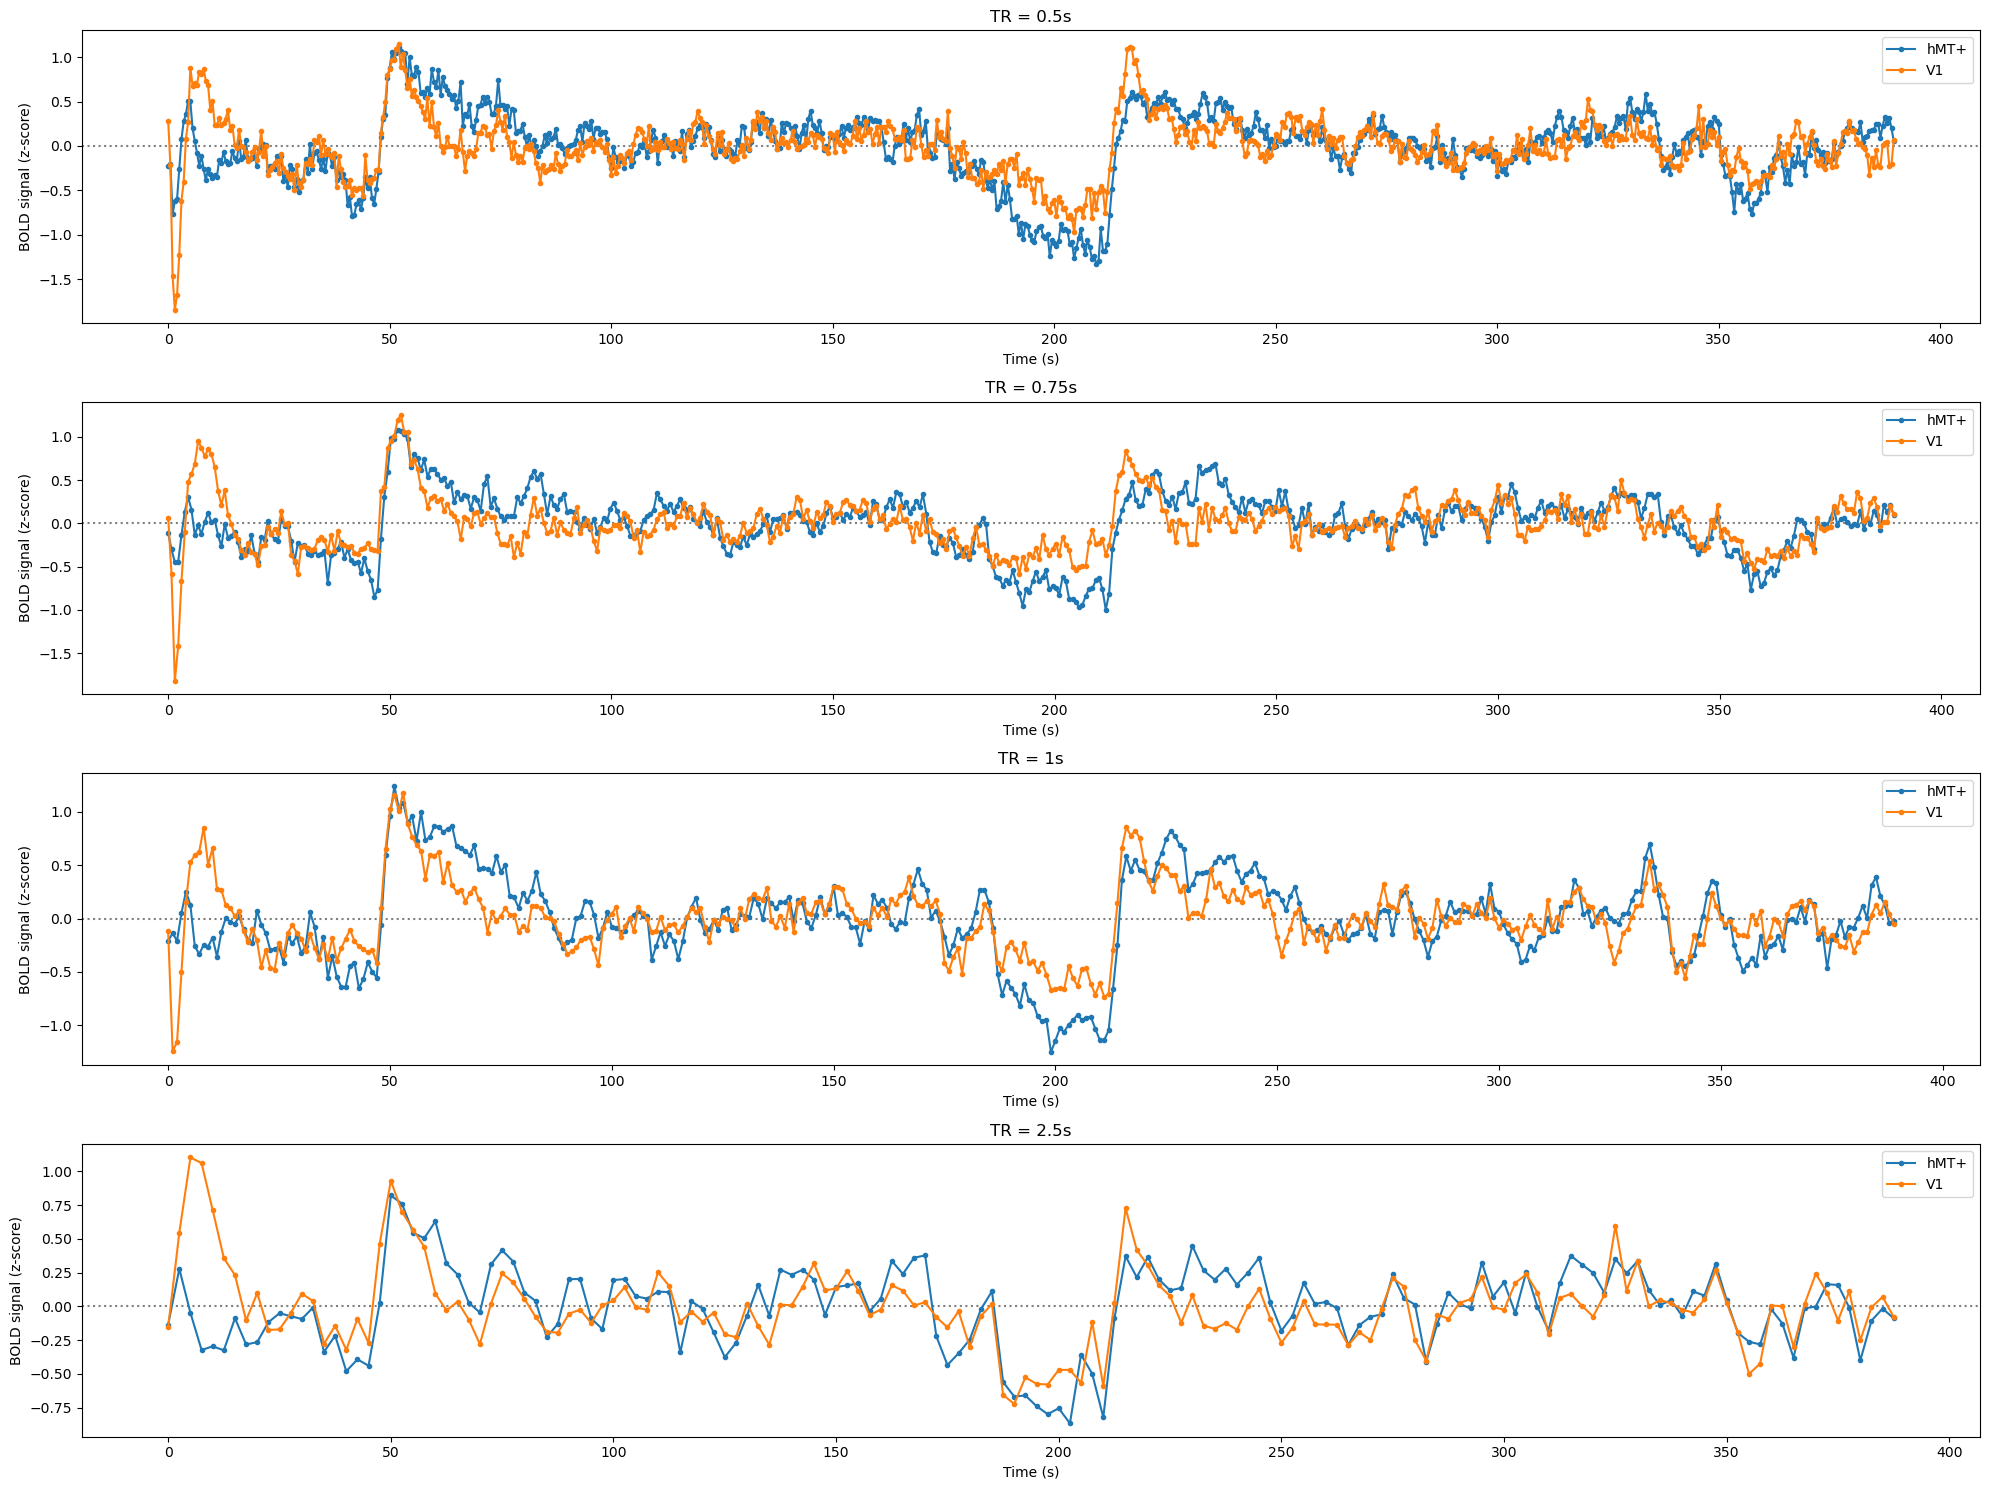

In [7]:
# Plot timecourses per TR
f, axs = plt.subplots(len(tr_list), 1, figsize=(20, 15))

for tr_idx, tr in enumerate(tr_list):

    n_volumes = n_volumes_list[tr_idx]

    m1 = df[df['tr']==tr]['bilateral_mt'].mean()
    s1 = df[df['tr']==tr]['bilateral_mt'].values.std()
    m2 = df[df['tr']==tr]['bilateral_v1'].mean()
    s2 = df[df['tr']==tr]['bilateral_v1'].values.std()

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, n_volumes*tr, tr)

    # add horizontal line at y=0
    axs[tr_idx].axhline(y=0, color='k', linestyle=':', alpha=0.5)

    # plot m1 and m2 in different colors with legend
    axs[tr_idx].plot(time_vector, m1, label='hMT+', marker='.')
    axs[tr_idx].plot(time_vector, m2, label='V1', marker='.')
    axs[tr_idx].legend()

    # plot the standard deviation as a shaded area
    #axs[tr_idx].fill_between(time_vector, m1-s1, m1+s1, alpha=0.2)
    #axs[tr_idx].fill_between(time_vector, m2-s2, m2+s2, alpha=0.2)

    # add title and axis labels
    axs[tr_idx].set_title('TR = ' + str(tr) + 's')
    axs[tr_idx].set_xlabel('Time (s)')
    axs[tr_idx].set_ylabel('BOLD signal (z-score)')

plt.tight_layout()
plt.show()

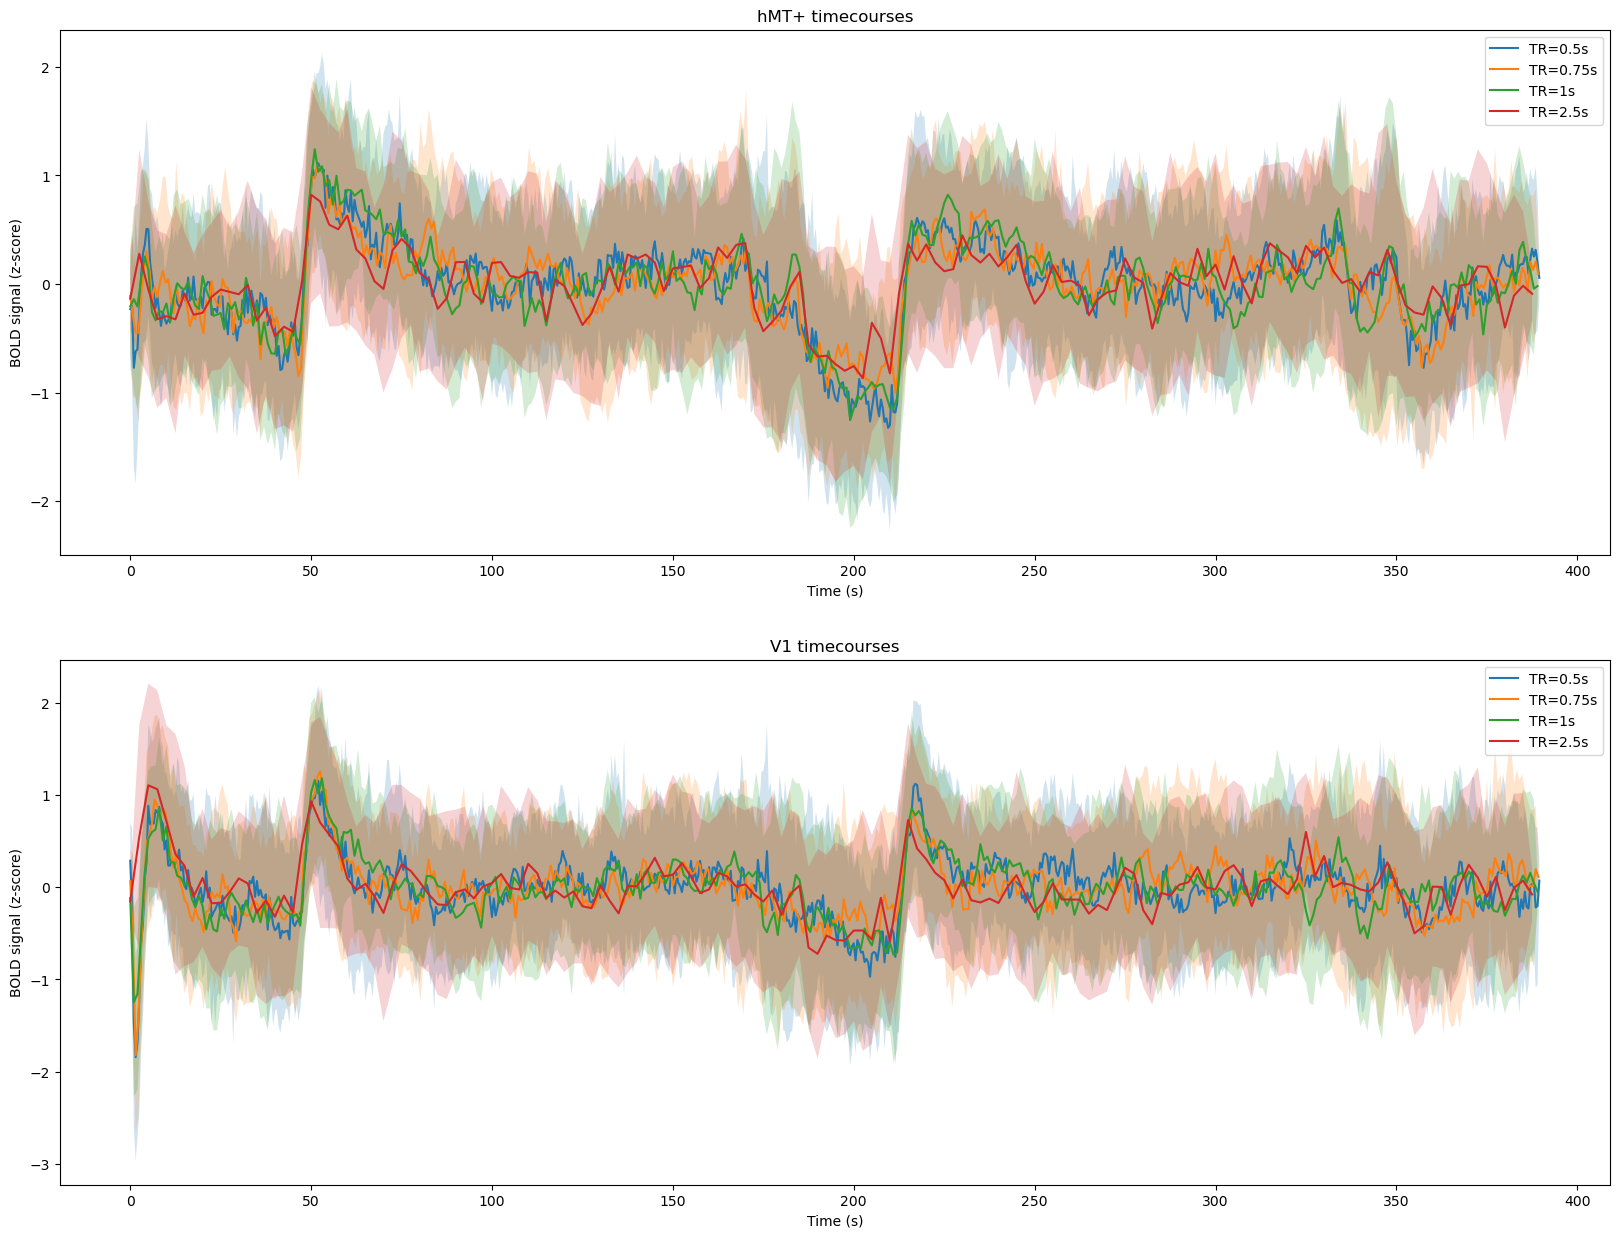

In [10]:
# Plot timecourses per ROI (bilateral_mt and bilateral_v1)
f, axs = plt.subplots(2, 1, figsize=(20, 15))

time_vectors = {}
# create time vectors for each TR
for tr_idx,tr in enumerate(tr_list):
    n_volumes = n_volumes_list[tr_idx]
    time_vectors[tr_idx] = np.arange(0, n_volumes*tr, tr)

# plot hMT+ timecourses for all TRs
for tr_idx,tr in enumerate(tr_list):
    m1 = df[df['tr']==tr]['bilateral_mt'].mean()
    s1 = df[df['tr']==tr]['bilateral_mt'].values.std()

    axs[0].plot(time_vectors[tr_idx], m1, label='TR='+str(tr)+'s')
    axs[0].fill_between(time_vectors[tr_idx], m1-s1, m1+s1, alpha=0.2)

axs[0].set_title('hMT+ timecourses')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('BOLD signal (z-score)')
axs[0].legend()

# plot V1 timecourses for all TRs
for tr_idx,tr in enumerate(tr_list):
    m1 = df[df['tr']==tr]['bilateral_v1'].mean()
    s1 = df[df['tr']==tr]['bilateral_v1'].values.std()

    axs[1].plot(time_vectors[tr_idx], m1, label='TR='+str(tr)+'s')
    axs[1].fill_between(time_vectors[tr_idx], m1-s1, m1+s1, alpha=0.2)

axs[1].set_title('V1 timecourses')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('BOLD signal (z-score)')
axs[1].legend()

plt.show()

In [ ]:
# Load sample events file per TR for sub-01
run_type = 'UA'
active_cond_name = 'Ambiguous' if run_type=='AA' else 'Unambiguous'

static_events_indexes_arr = np.zeros((len(tr_list), 500))
active_events_indexes_arr = np.zeros((len(tr_list), 500))

for tr_idx,tr in enumerate(tr_list):

    task_label = f'task-{run_type}_acq-{round(tr*1000):04}_run-1'
    events_file = os.path.join(data_dir, 'sub-01', 'func', f'sub-01_{task_label}_events.tsv')

    static_events_indexes, active_events_indexes = ff.read_events(events_file,hrf_delay,tr,active_cond_name)

    # save to array
    static_events_indexes_arr[tr_idx,:len(static_events_indexes)] = static_events_indexes
    active_events_indexes_arr[tr_idx,:len(active_events_indexes)] = active_events_indexes

verticalMarkers = np.array([15.5,45.5,164.5,179.5,209.5,329.5,344.5,374.5]) + hrf_delay # these mark the change of condition (including hrf_delay)

In [ ]:
# plot ERA with mean PSC to static timeseries for each tr
f_psc, axs_psc = plt.subplots(4, 1, figsize=(20, 20))

for tr_idx,tr in enumerate(tr_list):

    # extract static_events_indexes for each tr excluding zeros
    static_events_indexes_aux = static_events_indexes_arr[tr_idx,static_events_indexes_arr[tr_idx,:] > 0]
    active_events_indexes_aux = active_events_indexes_arr[tr_idx,active_events_indexes_arr[tr_idx,:] > 0]

    time_series = df[df['tr']==tr][roi_name]
    time_series = np.array(time_series.tolist()) # convert time_series to numpy array
    time_series_static = time_series[:,static_events_indexes_aux.astype(int)]

    # calculate mean of each row
    m = time_series_static.mean(axis=1)

    # substrat m from time_series and divide by abs(m)
    time_series_psc = (time_series - m[:,None]) / abs(m[:,None])

    time_series_mean = time_series_psc.mean(axis=0)
    time_series_std = time_series_psc.std(axis=0)

    # estimate event related response
    time_series_mean_active = time_series_mean[active_events_indexes_aux.astype(int)]
    time_series_mean_active_length = time_series_mean_active.shape[0]//2

    # reshape time_series_mean_active to two columns with half the points each
    time_series_mean_active = time_series_mean_active.reshape((2,time_series_mean_active_length)).T

    # estimate mean and std
    time_series_mean_psc_active_mean = time_series_mean_active.mean(axis=1)
    time_series_mean_psc_active_std = time_series_mean_active.std(axis=1)

    # create time vector based on the number of time points and the tr
    time_vector = np.arange(0, time_series_mean_active_length*tr, tr)

    data_to_plot_mean = time_series_mean_psc_active_mean
    data_to_plot_std = time_series_mean_psc_active_std

    # plot mean and std timeseries
    axs_psc[tr_idx].plot(time_vector, data_to_plot_mean, marker = 'o', markerfacecolor = 'black')
    axs_psc[tr_idx].fill_between(time_vector, data_to_plot_mean-data_to_plot_std, data_to_plot_mean+data_to_plot_std, alpha=0.5)
    axs_psc[tr_idx].hlines(0, 0, time_vector[-1], colors='k', linestyles='dashed')
    axs_psc[tr_idx].set_title('Mean timeseries during AA and UA blocks for tr='+str(tr)+'s')
    axs_psc[tr_idx].set_xlabel('Time (seconds)')
    axs_psc[tr_idx].set_ylabel('PSC to static (%)')